In [2]:
import os
project_root = r'c:\Projects\traffic-congestion-prediction'
os.chdir(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

print("Libraries imported successfully!")
print("Working directory:", os.getcwd())

Libraries imported successfully!
Working directory: c:\Projects\traffic-congestion-prediction


In [3]:
import os
project_root = r'c:\Projects\traffic-congestion-prediction'
os.chdir(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             RocCurveDisplay,
                             f1_score,
                             recall_score,
                             precision_score)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print("Working directory:", os.getcwd())

Libraries imported successfully!
TensorFlow version: 2.21.0
Working directory: c:\Projects\traffic-congestion-prediction


In [4]:
# Load preprocessed data
X_train = pd.read_csv('data/processed/X_train.csv').values
X_val = pd.read_csv('data/processed/X_val.csv').values
X_test = pd.read_csv('data/processed/X_test.csv').values

y_train = pd.read_csv('data/processed/y_train.csv').squeeze().values
y_val = pd.read_csv('data/processed/y_val.csv').squeeze().values
y_test = pd.read_csv('data/processed/y_test.csv').squeeze().values

class_weights = joblib.load('models/class_weights.pkl')

# Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_lstm = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("Data loaded and reshaped for LSTM!")
print(f"X_train shape: {X_train_lstm.shape}")
print(f"X_val shape:   {X_val_lstm.shape}")
print(f"X_test shape:  {X_test_lstm.shape}")
print(f"Expected: (samples, 1, 12)")
print(f"\nClass weights: {class_weights}")

Data loaded and reshaped for LSTM!
X_train shape: (1297702, 1, 12)
X_val shape:   (278079, 1, 12)
X_test shape:  (278079, 1, 12)
Expected: (samples, 1, 12)

Class weights: {np.int64(0): np.float64(0.6246850585114833), np.int64(1): np.float64(2.5050517919673227)}


In [5]:
# Build LSTM model
def build_lstm(units_1=64, units_2=32, dropout=0.2):
    model = Sequential([
        LSTM(units_1, return_sequences=True,
             input_shape=(1, 12)),
        Dropout(dropout),
        LSTM(units_2, return_sequences=False),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm()
model.summary()

c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Use subset for faster training on CPU
SUBSET = 200000
indices = np.random.choice(len(X_train_lstm), 
                           SUBSET, replace=False)
X_train_sub = X_train_lstm[indices]
y_train_sub = y_train[indices]

print(f"Training on {SUBSET:,} samples")
print(f"Validation on {len(X_val_lstm):,} samples")

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Class weights dict with regular Python types
cw = {0: float(class_weights[0]), 
      1: float(class_weights[1])}

start = time.time()

history = model.fit(
    X_train_sub, y_train_sub,
    epochs=20,
    batch_size=1024,
    validation_data=(X_val_lstm, y_val),
    class_weight=cw,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start
print(f"\nTraining complete in {training_time:.1f}s")
print(f"Epochs trained: {len(history.history['loss'])}")

Training on 200,000 samples
Validation on 278,079 samples
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8113 - loss: 0.4555 - val_accuracy: 0.8452 - val_loss: 0.3587
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8675 - loss: 0.3046 - val_accuracy: 0.8817 - val_loss: 0.2844
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8737 - loss: 0.2912 - val_accuracy: 0.8777 - val_loss: 0.2928
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8769 - loss: 0.2841 - val_accuracy: 0.9028 - val_loss: 0.2436
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8794 - loss: 0.2805 - val_accuracy: 0.8917 - val_loss: 0.2610
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8803 - loss: 0.2770 - val_accuracy: 0.8797 - val_loss: 0.2853
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8796 - loss: 0.2755 - val_accuracy: 0.8732 - val_loss: 0.2957
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━

In [7]:
# Predict on validation set
y_val_prob = model.predict(X_val_lstm, 
                           batch_size=1024,
                           verbose=0).flatten()
y_val_pred = (y_val_prob > 0.5).astype(int)

print("=== LSTM Baseline – Validation Results ===")
print(classification_report(y_val, y_val_pred,
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_prob):.4f}")

=== LSTM Baseline – Validation Results ===
               precision    recall  f1-score   support

No Congestion       0.97      0.91      0.94    236537
   Congestion       0.63      0.85      0.72     41542

     accuracy                           0.90    278079
    macro avg       0.80      0.88      0.83    278079
 weighted avg       0.92      0.90      0.91    278079

AUC-ROC: 0.9517


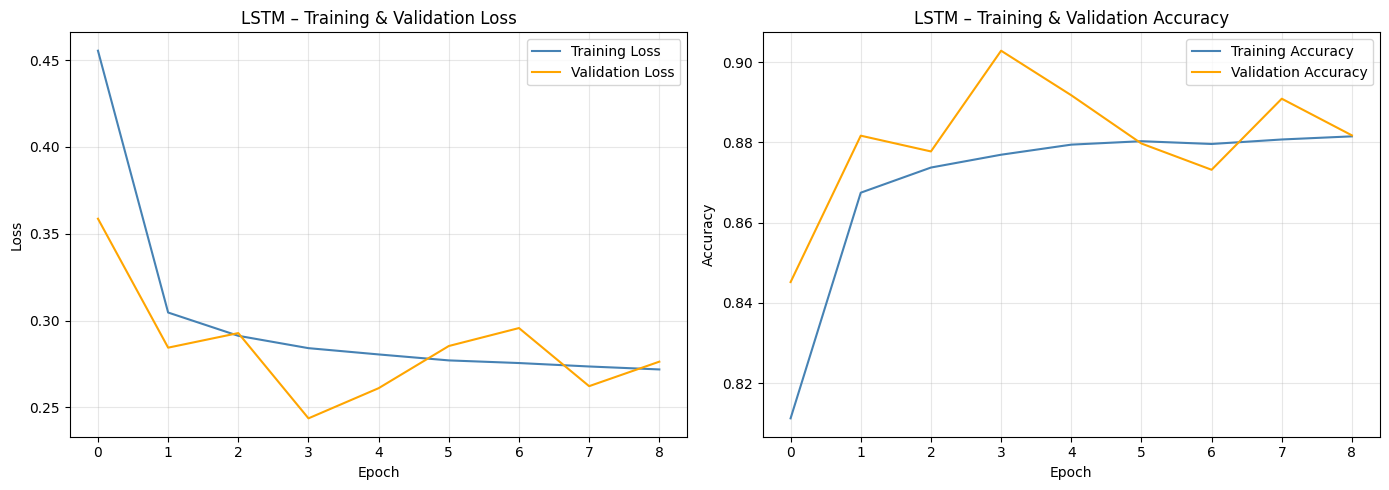

Plot saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], 
             label='Training Loss', color='steelblue')
axes[0].plot(history.history['val_loss'],
             label='Validation Loss', color='orange')
axes[0].set_title('LSTM – Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history.history['accuracy'],
             label='Training Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'],
             label='Validation Accuracy', color='orange')
axes[1].set_title('LSTM – Training & Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/lstm_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [9]:
print("=== LSTM Threshold Analysis ===")
print(f"{'Threshold':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10}")
print("-" * 45)

best_f1 = 0
best_threshold = 0.5

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    pred = (y_val_prob > threshold).astype(int)
    p = precision_score(y_val, pred)
    r = recall_score(y_val, pred)
    f1 = f1_score(y_val, pred)
    print(f"{threshold:>10.2f} {p:>10.4f} "
          f"{r:>10.4f} {f1:>10.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold}")
print(f"Best F1: {best_f1:.4f}")

=== LSTM Threshold Analysis ===
 Threshold  Precision     Recall         F1
---------------------------------------------
      0.30     0.5279     0.9164     0.6699
      0.35     0.5549     0.9029     0.6873
      0.40     0.5801     0.8873     0.7016
      0.45     0.6048     0.8718     0.7142
      0.50     0.6285     0.8547     0.7244

Best threshold: 0.5
Best F1: 0.7244


In [10]:
configs = [
    {'units_1': 64,  'units_2': 32, 'dropout': 0.2},
    {'units_1': 128, 'units_2': 64, 'dropout': 0.2},
    {'units_1': 64,  'units_2': 32, 'dropout': 0.3},
]

tuning_results = []

# Store baseline
tuning_results.append({
    'config': 'Baseline (64-32, dropout=0.2)',
    'f1': f1_score(y_val, y_val_pred),
    'recall': recall_score(y_val, y_val_pred),
    'time': 32.3
})

for i, cfg in enumerate(configs[1:], 2):
    print(f"\nTraining Config {i}: "
          f"units={cfg['units_1']}-{cfg['units_2']}, "
          f"dropout={cfg['dropout']}...")

    m = build_lstm(**cfg)
    es = EarlyStopping(monitor='val_loss',
                       patience=5,
                       restore_best_weights=True,
                       verbose=0)
    start = time.time()
    m.fit(X_train_sub, y_train_sub,
          epochs=20,
          batch_size=1024,
          validation_data=(X_val_lstm, y_val),
          class_weight=cw,
          callbacks=[es],
          verbose=0)
    t = time.time() - start

    prob = m.predict(X_val_lstm,
                     batch_size=1024,
                     verbose=0).flatten()
    pred = (prob > 0.5).astype(int)
    f1 = f1_score(y_val, pred)
    recall = recall_score(y_val, pred)

    tuning_results.append({
        'config': f"Config {i} "
                  f"({cfg['units_1']}-{cfg['units_2']}, "
                  f"dropout={cfg['dropout']})",
        'f1': f1,
        'recall': recall,
        'time': t,
        'model': m
    })
    print(f"Done in {t:.1f}s – "
          f"F1: {f1:.4f}, Recall: {recall:.4f}")

print("\n=== LSTM Tuning Results ===")
for r in tuning_results:
    print(f"\n{r['config']}")
    print(f"  F1:     {r['f1']:.4f}")
    print(f"  Recall: {r['recall']:.4f}")
    print(f"  Time:   {r['time']:.1f}s")


Training Config 2: units=128-64, dropout=0.2...


c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done in 75.0s – F1: 0.7380, Recall: 0.8361

Training Config 3: units=64-32, dropout=0.3...


c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Done in 40.9s – F1: 0.7216, Recall: 0.8659

=== LSTM Tuning Results ===

Baseline (64-32, dropout=0.2)
  F1:     0.7244
  Recall: 0.8547
  Time:   32.3s

Config 2 (128-64, dropout=0.2)
  F1:     0.7380
  Recall: 0.8361
  Time:   75.0s

Config 3 (64-32, dropout=0.3)
  F1:     0.7216
  Recall: 0.8659
  Time:   40.9s


In [11]:
best_lstm = tuning_results[1]['model']
BEST_THRESHOLD = 0.5

y_test_prob_lstm = best_lstm.predict(
    X_test_lstm, batch_size=1024, verbose=0).flatten()
y_test_pred_lstm = (
    y_test_prob_lstm > BEST_THRESHOLD).astype(int)

print("=== LSTM Final Results (Test Set) ===")
print(f"Config: 128-64 units, dropout=0.2, threshold=0.5")
print()
print(classification_report(y_test, y_test_pred_lstm,
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_prob_lstm):.4f}")

=== LSTM Final Results (Test Set) ===
Config: 128-64 units, dropout=0.2, threshold=0.5

               precision    recall  f1-score   support

No Congestion       0.97      0.92      0.94    232691
   Congestion       0.68      0.85      0.75     45388

     accuracy                           0.91    278079
    macro avg       0.82      0.88      0.85    278079
 weighted avg       0.92      0.91      0.91    278079

AUC-ROC: 0.9581


c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


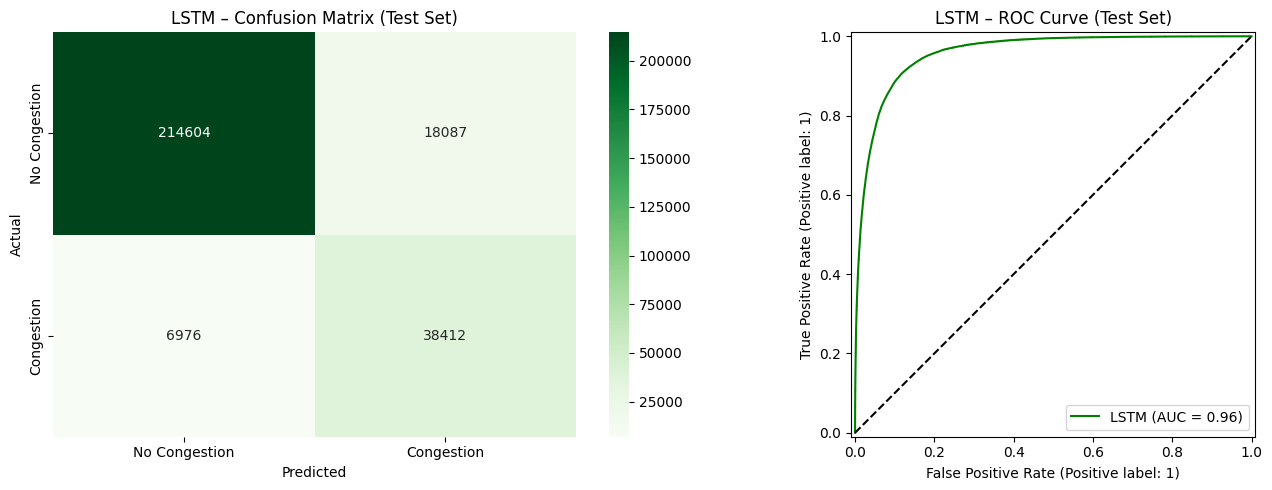

True Negatives:  214,604
False Positives: 18,087
False Negatives: 6,976
True Positives:  38,412


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_test_pred_lstm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Congestion', 'Congestion'],
            yticklabels=['No Congestion', 'Congestion'],
            ax=axes[0])
axes[0].set_title('LSTM – Confusion Matrix (Test Set)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(
    y_test, y_test_prob_lstm,
    name='LSTM',
    color='green',
    ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('LSTM – ROC Curve (Test Set)')

plt.tight_layout()
plt.savefig('results/figures/lstm_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

In [13]:
best_lstm.save('models/lstm_best.keras')
print("LSTM model saved!")
size = os.path.getsize('models/lstm_best.keras')
print(f"Model size: {size/1024/1024:.1f} MB")

LSTM model saved!
Model size: 1.4 MB


In [14]:
def build_lstm_v2():
    model = Sequential([
        LSTM(128, return_sequences=True,
             input_shape=(1, 12)),
        Dropout(0.3),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Training deeper LSTM (3 layers, dropout=0.3)...")
model_v2 = build_lstm_v2()
model_v2.summary()

es = EarlyStopping(monitor='val_loss',
                   patience=5,
                   restore_best_weights=True,
                   verbose=1)

start = time.time()
history_v2 = model_v2.fit(
    X_train_sub, y_train_sub,
    epochs=20,
    batch_size=1024,
    validation_data=(X_val_lstm, y_val),
    class_weight=cw,
    callbacks=[es],
    verbose=1
)
t = time.time() - start

prob_v2 = model_v2.predict(
    X_val_lstm, batch_size=1024, verbose=0).flatten()
pred_v2 = (prob_v2 > 0.5).astype(int)

print(f"\nDone in {t:.1f}s")
print(f"\n=== Deeper LSTM – Validation Results ===")
print(classification_report(y_val, pred_v2,
      target_names=['No Congestion', 'Congestion']))
print(f"AUC-ROC: {roc_auc_score(y_val, prob_v2):.4f}")
print(f"\nF1:     {f1_score(y_val, pred_v2):.4f}")
print(f"Recall: {recall_score(y_val, pred_v2):.4f}")

Training deeper LSTM (3 layers, dropout=0.3)...


c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 128)         │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,561 (525.63 KB)

 Trainable params: 134,561 (525.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8190 - loss: 0.4298 - val_accuracy: 0.8460 - val_loss: 0.3582
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8717 - loss: 0.2998 - val_accuracy: 0.8574 - val_loss: 0.3350
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8769 - loss: 0.2897 - val_accuracy: 0.8849 - val_loss: 0.2801
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8797 - loss: 0.2832 - val_accuracy: 0.8886 - val_loss: 0.2727
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8807 - loss: 0.2809 - val_accuracy: 0.8889 - val_loss: 0.2686
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8808 - loss: 0.2780 - val_accuracy: 0.8863 - val_loss: 0.2734
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8824 - loss: 0.2752 - val_accuracy: 0.8923 - val_loss: 0.2604
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8824 - loss: 0.2743 - val_accu